# Antasena Super Course — Perbandingan Efisiensi

**Tujuan:** membandingkan dua (atau lebih) data telemetri — tegangan, arus, kecepatan, jarak terhadap waktu — dan mencari tahu *mengapa* satu percobaan lebih hemat energi daripada yang lain.

Notebook ini langsung bisa dipakai dengan dua data contoh di `data/` (`105V / 9A` vs `80V / 12A`). Setelah kamu mengumpulkan data sendiri dengan `subscriber.py`, cukup arahkan daftar `ATTEMPTS` di sel konfigurasi di bawah ke file CSV milikmu lalu jalankan ulang semuanya.

## Persiapan (khusus Google Colab)

Jika kamu membuka notebook ini di **Google Colab**, jalankan sel di bawah terlebih dahulu. Sel ini mengunduh data dan skrip kursus ke Colab. Di Jupyter lokal, sel ini tidak melakukan apa-apa.

In [1]:
import os, sys

if "google.colab" in sys.modules and not os.path.exists("data"):
    if not os.path.exists("/content/ASC_Simulator"):
        !git clone -q https://github.com/Antasena-ITS-Team/ASC_Simulator.git /content/ASC_Simulator
    %cd /content/ASC_Simulator

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Konfigurasi

Setiap baris berisi `(path_csv, label)`. Tambah atau ganti baris di sini untuk membandingkan percobaanmu sendiri — semua sel di bawah otomatis menyesuaikan dengan jumlah percobaan yang kamu tulis.

In [3]:
ATTEMPTS = [
    ("data/DataASC_105V_9A.csv", "105V / 9A"),
    ("data/DataASC_80V_12A.csv", "80V / 12A"),
]

PALETTE = ["#2563eb", "#dc2626", "#16a34a", "#d97706"]
COLORS = {label: PALETTE[i % len(PALETTE)] for i, (_, label) in enumerate(ATTEMPTS)}

## Langkah 1 — Memuat data dan menghitung besaran turunan

Dari kolom sensor mentah (`voltage_V`, `current_A`, `distance_m`, `time_s`) kita menghitung:

- `power_W = voltage_V * current_A` (daya = tegangan × arus)
- `energy_Wh` — integral berjalan (kumulatif) daya terhadap waktu, dalam watt-jam
- `efficiency_km_per_kWh = distance_m / energy_Wh` — seberapa jauh mobil melaju per satuan energi yang dipakai, dihitung kumulatif sejak awal balapan

Jika sebuah file memakai `speed_kmh` alih-alih `speed_ms`, kolom itu otomatis dikonversi agar semua percobaan bisa dibandingkan dengan satuan yang sama.

In [4]:
def load_attempt(path, label):
    df = pd.read_csv(path)

    if "speed_kmh" in df.columns:
        df["speed_ms"] = df["speed_kmh"] / 3.6

    df["power_W"] = df["voltage_V"] * df["current_A"]
    df["dt_s"] = df["time_s"].diff().fillna(0)
    df["energy_Wh"] = (df["power_W"] * df["dt_s"] / 3600).cumsum()
    df["efficiency_km_per_kWh"] = np.where(
        df["energy_Wh"] > 0, df["distance_m"] / df["energy_Wh"], np.nan
    )
    df["attempt"] = label
    return df


data = {label: load_attempt(path, label) for path, label in ATTEMPTS}
combined = pd.concat(data.values(), ignore_index=True)

for label, df in data.items():
    print(f"--- {label} ---")
    display(df.head(3))

--- 105V / 9A ---


,lap,time_s,voltage_V,current_A,speed_kmh,distance_m,speed_ms,power_W,dt_s,energy_Wh,efficiency_km_per_kWh,attempt
0,1,0.008,104.996,0.0000,0.000,0.000,0.000000,0.000000,0.000,0.000000,NaN,105V / 9A
1,1,0.208,104.986,0.5582,0.439,0.011,0.121944,58.603185,0.200,0.003256,3.378656,105V / 9A
2,1,0.400,104.981,0.8003,0.897,0.047,0.249167,84.016294,0.192,0.007737,6.075019,105V / 9A


--- 80V / 12A ---


,lap,time_s,voltage_V,current_A,speed_kmh,distance_m,speed_ms,power_W,dt_s,energy_Wh,efficiency_km_per_kWh,attempt
0,1,0.008,79.994,0.0000,0.000,0.000,0.000000,0.000000,0.000,0.000000,NaN,80V / 12A
1,1,0.208,79.987,0.4242,0.285,0.008,0.079167,33.930485,0.200,0.001885,4.243971,80V / 12A
2,1,0.400,79.984,0.5483,0.567,0.030,0.157500,43.855227,0.192,0.004224,7.102319,80V / 12A


## Langkah 2 — Sinyal mentah terhadap waktu

Mulailah dengan melihat apa yang direkam setiap sensor, berdampingan.

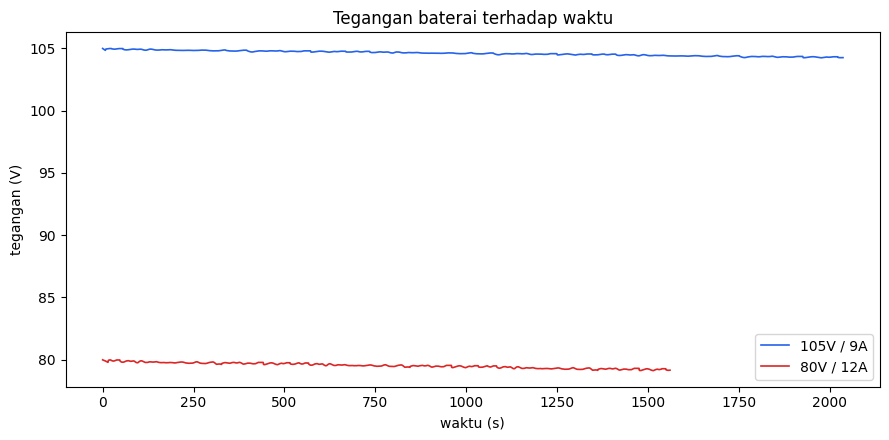

In [5]:
def plot_over_time(column, ylabel, title):
    plt.figure(figsize=(9, 4.5))
    for label, df in data.items():
        plt.plot(df["time_s"], df[column], label=label, color=COLORS[label], linewidth=1.2)
    plt.xlabel("waktu (s)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_over_time("voltage_V", "tegangan (V)", "Tegangan baterai terhadap waktu")

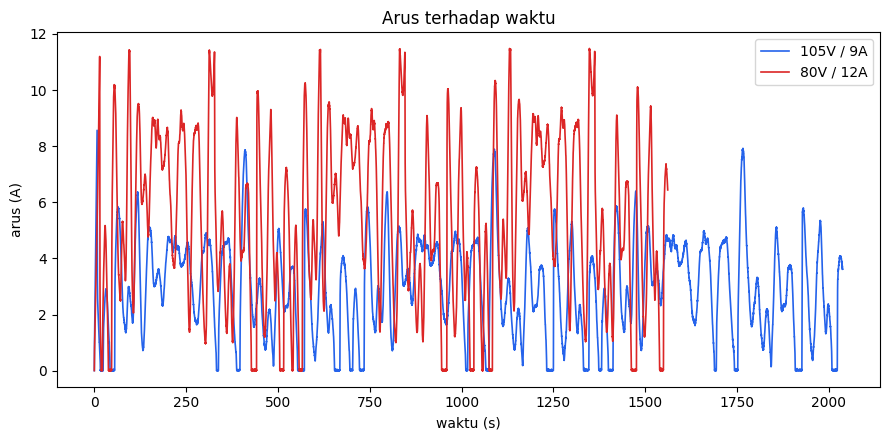

In [6]:
plot_over_time("current_A", "arus (A)", "Arus terhadap waktu")

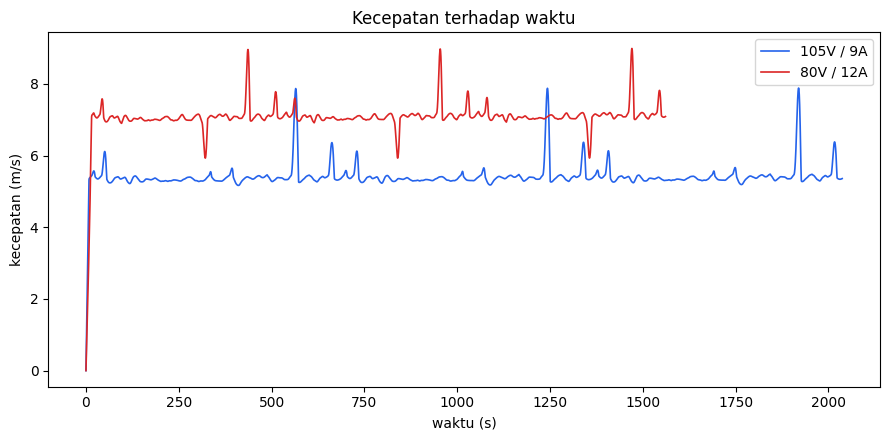

In [7]:
plot_over_time("speed_ms", "kecepatan (m/s)", "Kecepatan terhadap waktu")

## Langkah 3 — Daya dan energi

`power_W` menunjukkan konsumsi daya listrik sesaat. `energy_Wh` terhadap `distance_m` adalah grafik efisiensi utama: **garis yang lebih landai berarti jarak per watt-jam lebih jauh — artinya lebih efisien.**

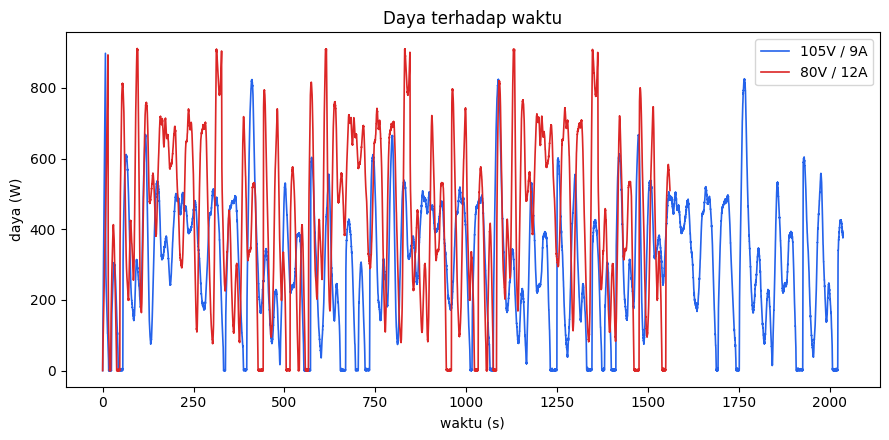

In [8]:
plot_over_time("power_W", "daya (W)", "Daya terhadap waktu")

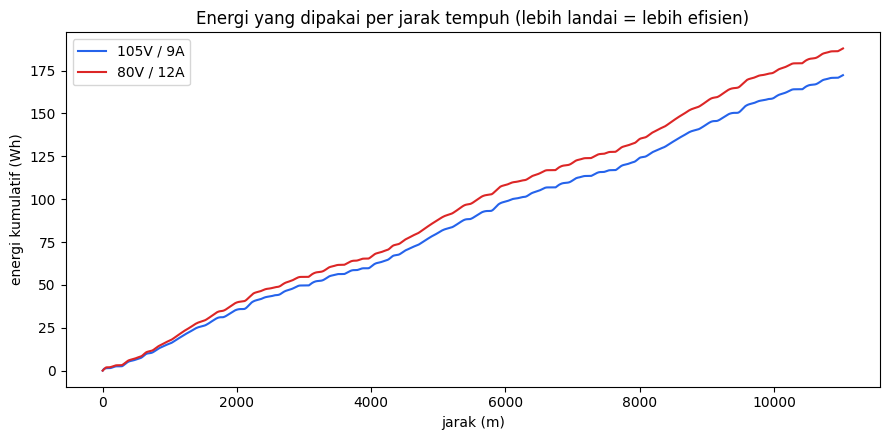

In [9]:
plt.figure(figsize=(9, 4.5))
for label, df in data.items():
    plt.plot(df["distance_m"], df["energy_Wh"], label=label, color=COLORS[label], linewidth=1.5)
plt.xlabel("jarak (m)")
plt.ylabel("energi kumulatif (Wh)")
plt.title("Energi yang dipakai per jarak tempuh (lebih landai = lebih efisien)")
plt.legend()
plt.tight_layout()
plt.show()

## Langkah 4 — Perbandingan efisiensi

`efficiency_km_per_kWh` masih naik-turun di awal (karena dibagi nilai energi yang sangat kecil) lalu stabil seiring berjalannya balapan — nilai yang sudah stabil itulah yang perlu kamu bandingkan antar percobaan.

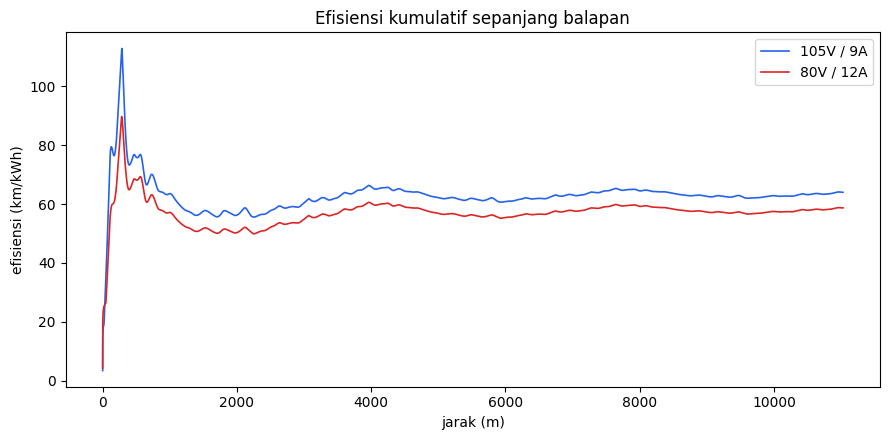

105V / 9A: efisiensi akhir = 64.00 km/kWh
80V / 12A: efisiensi akhir = 58.69 km/kWh


In [10]:
plt.figure(figsize=(9, 4.5))
for label, df in data.items():
    plt.plot(df["distance_m"], df["efficiency_km_per_kWh"], label=label, color=COLORS[label], linewidth=1.2)
plt.xlabel("jarak (m)")
plt.ylabel("efisiensi (km/kWh)")
plt.title("Efisiensi kumulatif sepanjang balapan")
plt.legend()
plt.tight_layout()
plt.show()

for label, df in data.items():
    final_eff = df["efficiency_km_per_kWh"].iloc[-1]
    print(f"{label}: efisiensi akhir = {final_eff:.2f} km/kWh")

### Ringkasan per lap

Memecah balapan per `lap` menunjukkan apakah efisiensi konsisten dalam satu percobaan, dan memberi angka yang rapi untuk dibandingkan antar percobaan.

In [11]:
summaries = []
for label, df in data.items():
    g = df.groupby("lap").agg(
        distance_start=("distance_m", "first"), distance_end=("distance_m", "last"),
        energy_start=("energy_Wh", "first"), energy_end=("energy_Wh", "last"),
        avg_speed_ms=("speed_ms", "mean"), max_speed_ms=("speed_ms", "max"),
        avg_current_A=("current_A", "mean"),
    )
    g["lap_distance_m"] = g["distance_end"] - g["distance_start"]
    g["lap_energy_Wh"] = g["energy_end"] - g["energy_start"]
    g["lap_efficiency_km_per_kWh"] = g["lap_distance_m"] / g["lap_energy_Wh"]
    g["attempt"] = label
    summaries.append(g.reset_index()[[
        "attempt", "lap", "lap_distance_m", "lap_energy_Wh",
        "lap_efficiency_km_per_kWh", "avg_speed_ms", "max_speed_ms", "avg_current_A",
    ]])

lap_summary = pd.concat(summaries, ignore_index=True)
lap_summary

,attempt,lap,lap_distance_m,lap_energy_Wh,lap_efficiency_km_per_kWh,avg_speed_ms,max_speed_ms,avg_current_A
0,105V / 9A,1,3675.039,57.873229,63.501537,5.379898,7.871944,2.909516
1,105V / 9A,2,3675.322,57.191664,64.263246,5.424066,7.878889,2.905463
2,105V / 9A,3,3674.514,57.200515,64.239176,5.435650,7.885833,2.918967
3,80V / 12A,1,3675.559,63.327565,58.040429,6.970485,8.961389,5.420072
4,80V / 12A,2,3674.343,62.216124,59.057729,7.101534,8.976667,5.444764
5,80V / 12A,3,3675.009,62.296830,58.991910,7.122207,8.991389,5.483262


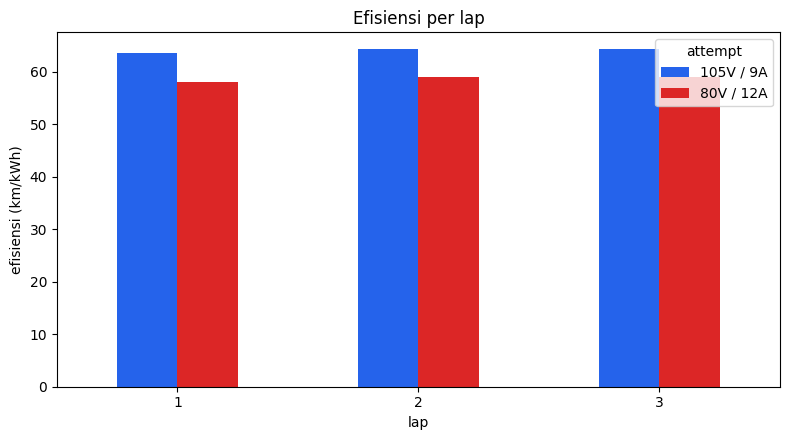

In [12]:
pivot = lap_summary.pivot(index="lap", columns="attempt", values="lap_efficiency_km_per_kWh")
pivot.plot(kind="bar", color=[COLORS[c] for c in pivot.columns], figsize=(8, 4.5))
plt.ylabel("efisiensi (km/kWh)")
plt.title("Efisiensi per lap")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Langkah 5 — Mengapa efisiensinya berbeda?

Gunakan grafik-grafik di atas (dan grafik tambahan ini) untuk menjawab:

1. Percobaan mana yang efisiensinya lebih tinggi, dan kira-kira berapa persen selisihnya?
2. Bandingkan `avg_current_A` antar percobaan. Rugi-rugi listrik sebanding dengan **kuadrat arus** (`P_rugi ≈ I² × R`) — bagaimana hal ini bisa menjelaskan sebagian perbedaannya?
3. Apakah percobaan yang lebih efisien juga mencapai kecepatan puncak lebih tinggi (`max_speed_ms`)? Apa artinya bagi tarik-ulur antara kecepatan dan efisiensi?
4. Lihat grafik arus terhadap kecepatan di bawah: pada kecepatan yang mirip, apakah salah satu percobaan menarik arus jauh lebih besar? Apa penyebabnya (rasio gir, ukuran motor, hambatan aerodinamis, gaya mengemudi)?

Tulis jawabanmu di sel markdown baru di bawah.

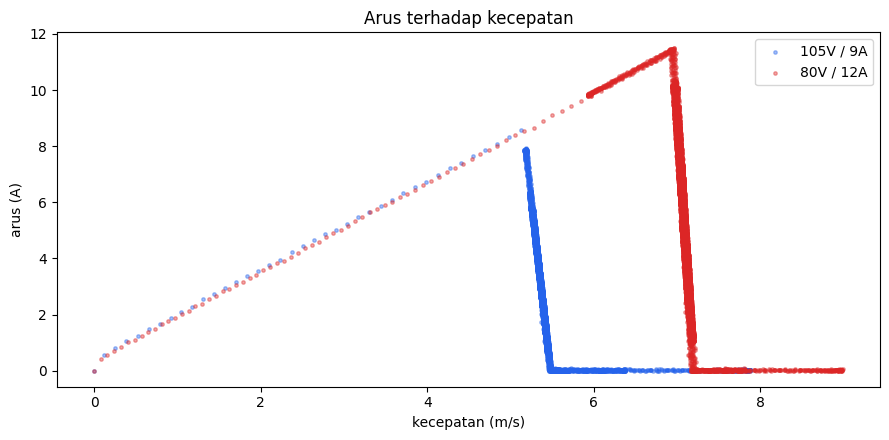

In [13]:
plt.figure(figsize=(9, 4.5))
for label, df in data.items():
    plt.scatter(df["speed_ms"], df["current_A"], label=label, color=COLORS[label], s=6, alpha=0.4)
plt.xlabel("kecepatan (m/s)")
plt.ylabel("arus (A)")
plt.title("Arus terhadap kecepatan")
plt.legend()
plt.tight_layout()
plt.show()

_Tulis jawabanmu di sini._

## Langkah 6 — Giliranmu

1. Jalankan `publisher.py` untuk satu data rekaman sementara `subscriber.py --out attempt_a.csv` sedang mendengarkan; ulangi untuk percobaan kedua ke `attempt_b.csv`.
2. Ubah daftar `ATTEMPTS` di sel konfigurasi agar menunjuk ke kedua file tersebut.
3. Jalankan ulang seluruh notebook (Kernel → Restart & Run All) dan tuliskan penjelasanmu sendiri tentang perbedaan efisiensinya.

### Memakai data rekamanmu sendiri di Colab

Setiap notebook Colab berjalan di mesinnya sendiri, jadi file yang direkam di notebook lain **tidak otomatis ada di sini**. Pilih salah satu cara:

- **Cara A:** rekam dengan notebook [rekam_data.ipynb](https://colab.research.google.com/github/Antasena-ITS-Team/ASC_Simulator/blob/master/rekam_data.ipynb), unduh CSV-nya, lalu jalankan sel unggah di bawah.
- **Cara B:** rekam langsung di notebook ini dengan sel rekam di bawah (jalankan saat instruktur sedang menyiarkan data).

Setelah itu, ubah `ATTEMPTS` di sel konfigurasi ke nama file-mu dan jalankan ulang semua sel. Di komputer lokal, cukup jalankan `python subscriber.py` di terminal seperti di README.

⚠️ Di Colab, file akan **hilang saat runtime berakhir**. Unduh CSV-mu lewat panel **Files** di kiri.

In [ ]:
# Cara A: unggah CSV hasil rekaman (khusus Colab)
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    print("Tersimpan:", list(uploaded))

In [ ]:
# Cara B: rekam langsung di sini (khusus Colab)
!pip install -q paho-mqtt

OUT_FILE = "attempt_a.csv"   # ganti ke attempt_b.csv untuk percobaan kedua
DURASI_S = 300              # berapa detik merekam
!timeout {DURASI_S} python -u subscriber.py --out {OUT_FILE} | grep -v "^Received"